In [1]:
# Importing libraries for Geospatial work

import geopandas as gpd
import rasterio
import xarray as xr
import leafmap
import pandas as pd
import numpy as np

buildings_path = "LIST_2D_BUILDING_POLYS_HOBART/list_2d_building_polys_hobart.shp"
buildings = gpd.read_file(buildings_path)

print(f"Loaded {len(buildings):,} building polygons")
print(buildings.crs)
print(buildings.columns.tolist())
buildings.head()

Loaded 23,399 building polygons
EPSG:28355
['BUILD_ID', 'BUILD_TY', 'BUILD_NAME', 'BLD_PUR', 'MEAN_HGT', 'NOM_REG_NO', 'FEAT_REL', 'UFI', 'CREATED_ON', 'LIST_GUID', 'CRC_ID', 'SHAPE_AREA', 'SHAPE_LEN', 'geometry']


,BUILD_ID,BUILD_TY,BUILD_NAME,BLD_PUR,MEAN_HGT,NOM_REG_NO,FEAT_REL,UFI,CREATED_ON,LIST_GUID,CRC_ID,SHAPE_AREA,SHAPE_LEN,geometry
0,51126,Administration Facility,NaN,Operations,0.0,NaN,2010-01-30,{5ccb62ca-e058-4745-b0f5-5beecd402611},2022-06-17 09:50:46,{f6835cd6-7257-4b0b-b4d8-44bd23f74ac8},495711D7C5BCE27B,472.254060,96.993661,"POLYGON ((519308.274 5250844.835, 519310.682 5..."
1,617936,Shed,NaN,Rural Medium,0.0,NaN,2010-01-30,{a86d7b93-5c7b-405a-ae70-26c6778877d8},2022-06-17 09:50:46,{31aae316-6a35-4833-89bb-f7b2405313d6},F19F25705C41F16B,4.000000,8.000000,"POLYGON ((520057.282 5248600.697, 520055.282 5..."
2,185180,Residential Building,NaN,Not Applicable,0.0,NaN,2019-02-05,{10a45e24-7662-46a5-89f6-6299643b331d},2022-06-17 09:50:46,{6b1e5bc9-07fe-4320-b1ec-ec7f837b39ff},4660C36D7DC4C34C,126.544997,44.997217,"POLYGON ((520158.323 5246711.465, 520147.167 5..."
3,185167,Residential Building,NaN,Not Applicable,0.0,NaN,2019-02-05,{bd933fb6-3479-4ee1-805d-e9ecfddb7075},2022-06-17 09:50:46,{d513418b-ff14-4ce4-9f0b-7cf02457fc74},863804F3C0602CED,237.635166,90.714124,"POLYGON ((520196.565 5246620.004, 520196.474 5..."
4,463449,Residential Building,NaN,Not Applicable,0.0,NaN,2016-01-01,{7c46c4fe-98b8-4f9a-8879-851d803da899},2022-06-17 09:50:46,{aedc2626-021f-4cb5-99b5-b28d7a5d0cbd},10EC7ABA018867B6,150.247616,49.181277,"POLYGON ((520218.14 5246657.074, 520212.132 52..."


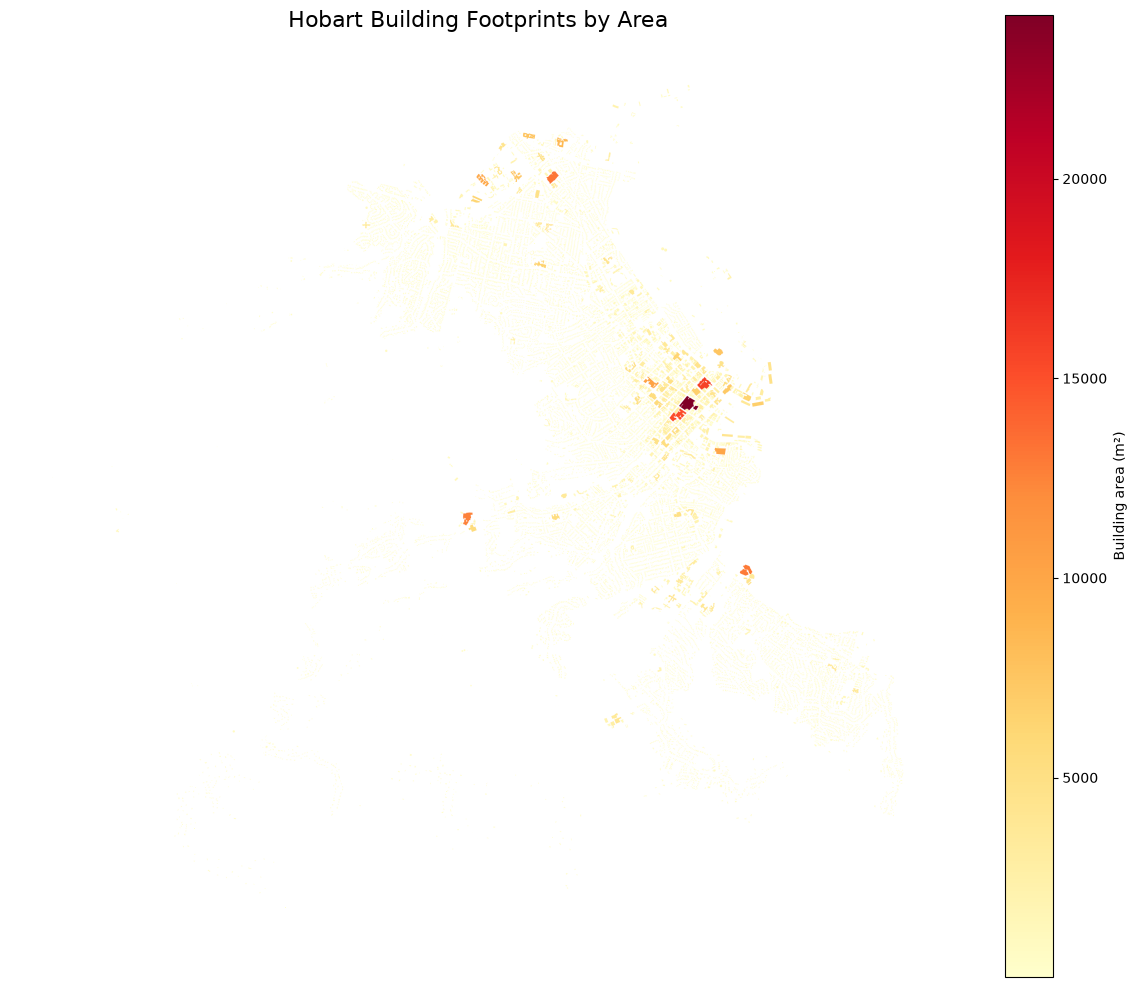

In [2]:
# Choropleth map of building footprints by area

import matplotlib.pyplot as plt

buildings["area_m2"] = pd.to_numeric(buildings["SHAPE_AREA"], errors="coerce")

fig, ax = plt.subplots(figsize=(12, 10))
buildings.plot(
    ax=ax,
    column="area_m2",
    cmap="YlOrRd",
    linewidth=0.05,
    edgecolor="white",
    legend=True,
    legend_kwds={"label": "Building area (m²)", "orientation": "vertical"},
    missing_kwds={"color": "lightgrey", "label": "Missing area"},
)

ax.set_title("Hobart Building Footprints by Area", fontsize=16, pad=12)
ax.set_axis_off()
plt.tight_layout()
plt.show()